# 🎨 AI Text-to-Image Generator
Generate images from text prompts using Hugging Face Inference API and Gradio UI.
Uses `InferenceClient` for reliable connection handling and auto-retry.

In [1]:
# Step 1: Install required packages
%pip install -q gradio huggingface-hub Pillow

In [2]:
# Step 2: Load your Hugging Face token (same as your Text Summarizer)
import os
import getpass

hf_token = getpass.getpass("Enter your Hugging Face API token (starts with hf_): ").strip()

if not hf_token.startswith("hf_"):
    raise ValueError("Invalid Hugging Face token. It must begin with 'hf_'.")

os.environ["HF_TOKEN"] = hf_token

print("Token loaded successfully.")

Enter your Hugging Face API token (starts with hf_): ··········
Token loaded successfully.


In [3]:
# Step 3: Import libraries
import gradio as gr
import time
from huggingface_hub import InferenceClient
from PIL import Image

In [4]:
# Step 4: Set up InferenceClient
# InferenceClient is the official HF library — more reliable than raw requests.
# It handles connection retries, model warm-up waits, and auth automatically.

client = InferenceClient(
    model="stabilityai/stable-diffusion-xl-base-1.0",
    token=os.environ["HF_TOKEN"],
    timeout=120   # Wait up to 120 seconds for response
)

print("✅ InferenceClient ready.")

✅ InferenceClient ready.


In [5]:
# Step 5: Define image generation function

def generate_image(prompt, negative_prompt, guidance_scale, num_steps):
    """
    Generate an image from a text prompt using Stable Diffusion XL.

    Args:
        prompt (str):           What you want to generate
        negative_prompt (str):  What to avoid in the image
        guidance_scale (float): How strictly to follow the prompt (1-20)
        num_steps (int):        Diffusion steps — more = better quality

    Returns:
        PIL.Image, str: Generated image and status message
    """

    if not prompt.strip():
        return None, "⚠️ Please enter a prompt to generate an image."

    if not negative_prompt.strip():
        negative_prompt = "blurry, ugly, distorted, deformed, low quality, watermark, text"

    MAX_RETRIES = 3

    for attempt in range(1, MAX_RETRIES + 1):
        try:
            print(f"🎨 Attempt {attempt}/{MAX_RETRIES} — generating image...")

            image = client.text_to_image(
                prompt=prompt,
                negative_prompt=negative_prompt,
                guidance_scale=guidance_scale,
                num_inference_steps=int(num_steps),
                height=512,
                width=512
            )

            return image, f"✅ Image generated successfully! (Steps: {int(num_steps)}, Guidance: {guidance_scale})"

        except Exception as e:
            error_msg = str(e)

            # Model is still warming up on HF servers — wait and retry
            if "loading" in error_msg.lower() or "503" in error_msg:
                wait = 20 * attempt
                print(f"⏳ Model is loading on HF servers. Waiting {wait}s before retry {attempt}/{MAX_RETRIES}...")
                time.sleep(wait)
                continue

            # Auth error — bad token
            elif "401" in error_msg or "unauthorized" in error_msg.lower():
                return None, "❌ Invalid token. Re-run Step 2 with a valid Hugging Face token."

            # Quota exceeded
            elif "429" in error_msg:
                return None, "❌ Rate limit hit. Wait a minute then try again (HF free tier limit)."

            # Any other error — retry
            else:
                print(f"⚠️ Attempt {attempt} failed: {error_msg[:120]}")
                if attempt < MAX_RETRIES:
                    time.sleep(10)
                    continue
                return None, f"❌ Failed after {MAX_RETRIES} attempts. Last error: {error_msg[:200]}"

    return None, "❌ Could not generate image. Please try again."

In [6]:
# Step 6: Build the Gradio UI — same style as your Text Summarizer

demo = gr.Interface(
    fn=generate_image,

    inputs=[
        gr.Textbox(
            lines=3,
            placeholder="Describe the image you want to generate...\nExample: A futuristic city at sunset, digital art, highly detailed",
            label="✏️ Prompt"
        ),
        gr.Textbox(
            lines=2,
            placeholder="What to avoid in the image (optional)...\nExample: blurry, cartoon, low quality",
            label="🚫 Negative Prompt (optional)"
        ),
        gr.Slider(
            minimum=1, maximum=20, value=7.5, step=0.5,
            label="🎯 Guidance Scale (higher = more faithful to prompt)"
        ),
        gr.Slider(
            minimum=10, maximum=50, value=30, step=5,
            label="🔁 Inference Steps (higher = better quality)"
        )
    ],

    outputs=[
        gr.Image(label="🖼️ Generated Image", type="pil"),
        gr.Textbox(label="Status")
    ],

    title="🎨 AI Text-to-Image Generator",
    description=(
        "Generate images from text using Stable Diffusion XL via Hugging Face Inference API.\n"
        "💡 Tip: Be descriptive! Add style keywords like 'digital art', 'photorealistic', 'watercolor', 'cinematic' etc."
    ),

    examples=[
        ["A majestic snow-capped mountain at golden hour, photorealistic, 4K",        "blurry, cartoon",      7.5, 30],
        ["A cozy coffee shop interior, warm lighting, watercolor painting style",      "low quality, dark",    8.0, 30],
        ["A futuristic robot in a neon-lit cyberpunk city, digital art, cinematic",   "blurry, ugly",         9.0, 35],
        ["Portrait of a lion wearing a business suit, oil painting, highly detailed", "cartoon, deformed",    7.5, 30],
        ["A traditional Pakistani bazaar at night, lanterns glowing, vibrant colors", "blurry, low quality",  8.0, 30]
    ],

    cache_examples=False
)

In [7]:
# Step 7: Launch the app
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8900bcb4545276e4f0.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


🎨 Attempt 1/3 — generating image...
Status: ✅ Image generated successfully! (Steps: 30, Guidance: 7.5)
Image saved as test_output.png


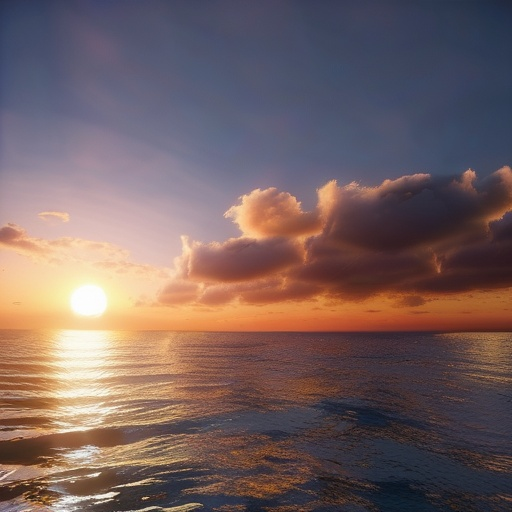

In [8]:
# Step 8 (optional): Test the function directly without Gradio UI
test_image, status = generate_image(
    prompt="A beautiful sunset over the ocean, photorealistic",
    negative_prompt="blurry, cartoon",
    guidance_scale=7.5,
    num_steps=30
)

print("Status:", status)

if test_image:
    test_image.save("test_output.png")
    print("Image saved as test_output.png")
    display(test_image)